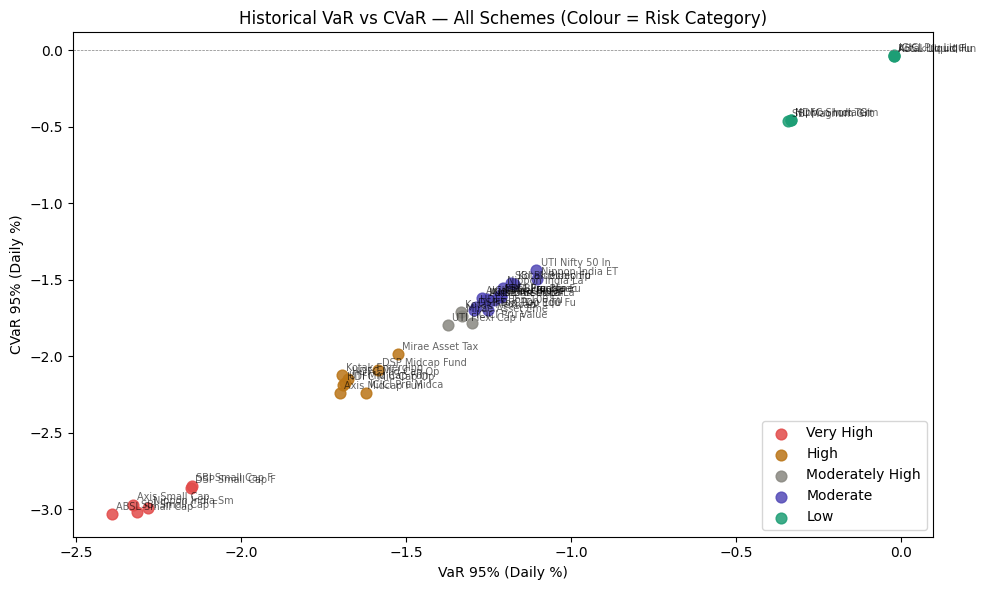


Top 10 Highest-Risk Funds
                                       scheme_name  var_95_pct  cvar_95_pct
            ABSL Small Cap Fund - Regular - Growth     -2.3915      -3.0289
            Axis Small Cap Fund - Regular - Growth     -2.3284      -2.9690
         SBI Small Cap Fund - Direct Plan - Growth     -2.3155      -3.0163
    Nippon India Small Cap Fund - Regular - Growth     -2.2810      -2.9940
             DSP Small Cap Fund - Regular - Growth     -2.1520      -2.8573
        SBI Small Cap Fund - Regular Plan - Growth     -2.1502      -2.8444
               Axis Midcap Fund - Regular - Growth     -1.6997      -2.2375
     Kotak Emerging Equity Fund - Regular - Growth     -1.6950      -2.1251
HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.6902      -2.1850
               UTI Mid Cap Fund - Regular - Growth     -1.6857      -2.1771

✅ Saved: data/processed/var_cvar_report.csv
✅ Saved: reports/charts/16_var_cvar_scatter.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from pathlib import Path

# -----------------------------
# Create output folders
# -----------------------------
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("reports/charts").mkdir(parents=True, exist_ok=True)

# -----------------------------
# Connect to SQLite
# -----------------------------
engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

# -----------------------------
# Load NAV data
# -----------------------------
query = """
SELECT
    n.amfi_code,
    n.date_id,
    n.nav,
    f.scheme_name,
    f.risk_category
FROM fact_nav n
JOIN dim_fund f
    ON n.amfi_code = f.amfi_code
ORDER BY n.amfi_code, n.date_id
"""

nav = pd.read_sql(query, engine)

# -----------------------------
# Prepare data
# -----------------------------
nav["date_id"] = pd.to_datetime(nav["date_id"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav = nav.dropna(subset=["daily_return"])

# -----------------------------
# Calculate VaR & CVaR
# -----------------------------
var_results = []

for code, grp in nav.groupby("amfi_code"):

    r = grp["daily_return"].values

    # Skip funds with insufficient history
    if len(r) < 30:
        continue

    # Historical VaR (95%)
    var_95 = np.percentile(r, 5)

    # Historical CVaR (Expected Shortfall)
    cvar_95 = r[r <= var_95].mean()

    var_results.append({
        "amfi_code": code,
        "scheme_name": grp["scheme_name"].iloc[0],
        "risk_category": grp["risk_category"].iloc[0],
        "var_95_pct": round(var_95 * 100, 4),
        "cvar_95_pct": round(cvar_95 * 100, 4),
        "worst_day_pct": round(r.min() * 100, 4),
        "best_day_pct": round(r.max() * 100, 4),
        "n_trading_days": len(r)
    })

# -----------------------------
# Results dataframe
# -----------------------------
var_df = pd.DataFrame(var_results)

if var_df.empty:
    raise ValueError(
        "No VaR results generated. Check fact_nav and dim_fund tables."
    )

var_df = var_df.sort_values("var_95_pct")

# Save CSV
csv_path = "data/processed/var_cvar_report.csv"
var_df.to_csv(csv_path, index=False)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {
    "Very High": "#E24B4A",
    "High": "#BA7517",
    "Moderate": "#534AB7",
    "Low": "#1D9E75"
}

for cat in var_df["risk_category"].dropna().unique():

    sub = var_df[var_df["risk_category"] == cat]

    ax.scatter(
        sub["var_95_pct"],
        sub["cvar_95_pct"],
        label=cat,
        color=colors_map.get(cat, "#888780"),
        s=60,
        alpha=0.85
    )

    for _, row in sub.iterrows():
        label = row["scheme_name"][:15]

        ax.annotate(
            label,
            (row["var_95_pct"], row["cvar_95_pct"]),
            fontsize=7,
            alpha=0.6,
            xytext=(3, 3),
            textcoords="offset points"
        )

ax.set_xlabel("VaR 95% (Daily %)")
ax.set_ylabel("CVaR 95% (Daily %)")
ax.set_title(
    "Historical VaR vs CVaR — All Schemes (Colour = Risk Category)"
)

ax.axhline(
    0,
    color="gray",
    linewidth=0.5,
    linestyle="--"
)

ax.legend()

plt.tight_layout()

chart_path = "reports/charts/16_var_cvar_scatter.png"

plt.savefig(
    chart_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# -----------------------------
# Output
# -----------------------------
print("\nTop 10 Highest-Risk Funds")
print(
    var_df[
        ["scheme_name", "var_95_pct", "cvar_95_pct"]
    ]
    .head(10)
    .to_string(index=False)
)

print(f"\n✅ Saved: {csv_path}")
print(f"✅ Saved: {chart_path}")

In [7]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

RF_DAILY = 0.065 / 252
WINDOW = 90

# Verify these codes exist in your dim_fund table
BLUECHIP_CODES = [119551, 120503, 118632, 119092, 120841]

fig = go.Figure()

colors = ["#534AB7", "#1D9E75", "#E24B4A", "#BA7517", "#0C447C"]

for code, color in zip(BLUECHIP_CODES, colors):

    grp = (
        nav[nav["amfi_code"] == code]
        .sort_values("date_id")
        .copy()
    )

    if grp.empty:
        print(f"AMFI {code} not found")
        continue

    r = grp["daily_return"]

    roll_mean = r.rolling(window=WINDOW, min_periods=WINDOW).mean()
    roll_std = r.rolling(window=WINDOW, min_periods=WINDOW).std()

    roll_sharpe = ((roll_mean - RF_DAILY) / roll_std) * np.sqrt(252)

    scheme_name = grp["scheme_name"].iloc[0]

    fig.add_trace(
        go.Scatter(
            x=grp["date_id"],
            y=roll_sharpe,
            mode="lines",
            name=scheme_name,
            line=dict(color=color, width=2)
        )
    )

fig.add_hline(
    y=1.0,
    line_dash="dot",
    line_color="green",
    annotation_text="Sharpe = 1.0"
)

fig.add_hline(
    y=0.0,
    line_dash="dash",
    line_color="red",
    annotation_text="Sharpe = 0"
)

fig.update_layout(
    title="Rolling 90-Day Sharpe Ratio — Bluechip Funds",
    xaxis_title="Date",
    yaxis_title="Rolling Sharpe (90D)",
    hovermode="x unified",
    height=500,
    template="plotly_white",
    legend=dict(orientation="h", y=-0.2)
)

import plotly.io as pio

pio.renderers.default = "browser"
fig.show()

# Save chart
try:
    fig.write_image(
        "../reports/charts/17_rolling_sharpe.png",
        scale=2
    )
    print("Saved: reports/charts/17_rolling_sharpe.png")
except Exception as e:
    print("Install kaleido first:")
    print("pip install kaleido")
    print(e)

Saved: reports/charts/17_rolling_sharpe.png


SIP records: 19,716

Cohort Analysis

 cohort_year  num_investors  avg_sip_amount  total_invested  avg_sips_per_investor                                  top_fund
        2024           4624        10996.89     214978121.0                    4.2 ICICI Pru Bluechip Fund - Direct - Growth
        2025            138        13505.21       2255370.0                    1.2 SBI Small Cap Fund - Direct Plan - Growth

Saved: data/processed/cohort_analysis.csv
Saved: reports/charts/18_cohort_analysis.png


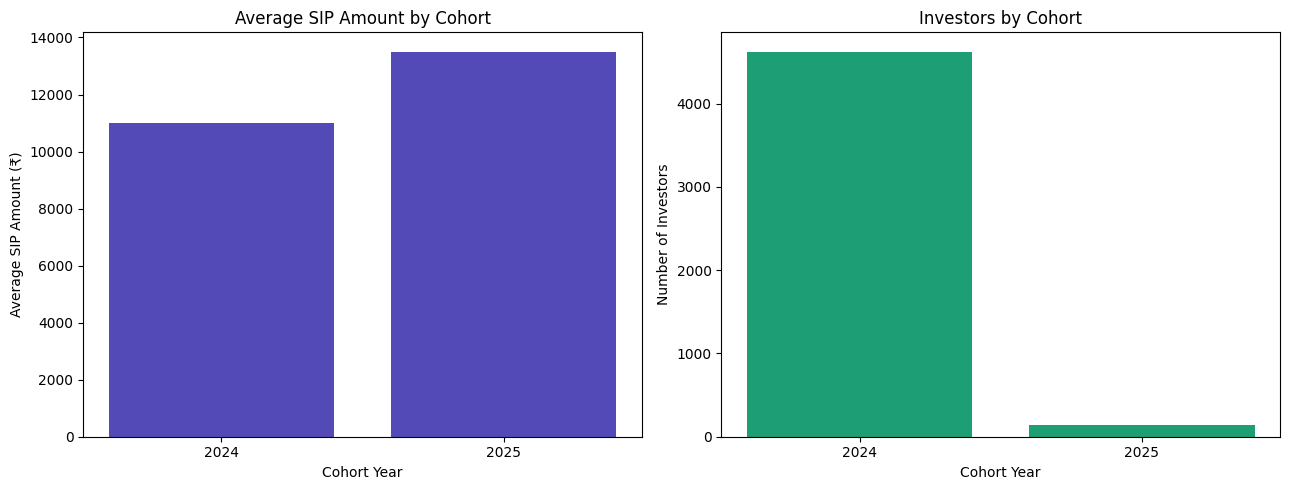

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load transactions
# --------------------------------------------------
txn = pd.read_sql("SELECT * FROM fact_transactions", engine)

# Convert date
txn["transaction_date"] = pd.to_datetime(txn["date_id"])

# --------------------------------------------------
# Assign cohort year
# --------------------------------------------------
first_txn = (
    txn.groupby("investor_id")["transaction_date"]
       .min()
)

txn["cohort_year"] = (
    txn["investor_id"]
       .map(first_txn)
       .dt.year
)

# --------------------------------------------------
# Filter SIP transactions
# --------------------------------------------------
sip = txn[
    txn["transaction_type"]
       .astype(str)
       .str.upper()
       .eq("SIP")
].copy()

print(f"SIP records: {len(sip):,}")

# --------------------------------------------------
# Cohort Metrics
# --------------------------------------------------
cohort = (
    sip.groupby("cohort_year")
       .agg(
           num_investors=("investor_id", "nunique"),
           avg_sip_amount=("amount_inr", "mean"),
           total_invested=("amount_inr", "sum"),
           num_sips=("id", "count")
       )
       .reset_index()
)

cohort["avg_sips_per_investor"] = (
    cohort["num_sips"] /
    cohort["num_investors"]
).round(1)

cohort["avg_sip_amount"] = (
    cohort["avg_sip_amount"]
    .round(2)
)

cohort["total_invested"] = (
    cohort["total_invested"]
    .round(2)
)

# --------------------------------------------------
# Top Fund per Cohort
# --------------------------------------------------
top_fund = (
    sip.groupby(["cohort_year", "amfi_code"])
       .size()
       .reset_index(name="txn_count")
       .sort_values(
           ["cohort_year", "txn_count"],
           ascending=[True, False]
       )
       .drop_duplicates("cohort_year")
)

funds = pd.read_sql(
    """
    SELECT amfi_code, scheme_name
    FROM dim_fund
    """,
    engine
)

top_fund = (
    top_fund.merge(
        funds,
        on="amfi_code",
        how="left"
    )
    [["cohort_year", "scheme_name"]]
    .rename(columns={
        "scheme_name": "top_fund"
    })
)

cohort = cohort.merge(
    top_fund,
    on="cohort_year",
    how="left"
)

# --------------------------------------------------
# Display Results
# --------------------------------------------------
print("\nCohort Analysis\n")

print(
    cohort[
        [
            "cohort_year",
            "num_investors",
            "avg_sip_amount",
            "total_invested",
            "avg_sips_per_investor",
            "top_fund"
        ]
    ].to_string(index=False)
)

# --------------------------------------------------
# Save CSV
# --------------------------------------------------
cohort.to_csv(
    "../data/processed/cohort_analysis.csv",
    index=False
)

print("\nSaved: data/processed/cohort_analysis.csv")

# --------------------------------------------------
# Visualization
# --------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# Avg SIP Amount
axes[0].bar(
    cohort["cohort_year"].astype(str),
    cohort["avg_sip_amount"],
    color="#534AB7"
)

axes[0].set_title(
    "Average SIP Amount by Cohort"
)
axes[0].set_xlabel("Cohort Year")
axes[0].set_ylabel("Average SIP Amount (₹)")

# Number of Investors
axes[1].bar(
    cohort["cohort_year"].astype(str),
    cohort["num_investors"],
    color="#1D9E75"
)

axes[1].set_title(
    "Investors by Cohort"
)
axes[1].set_xlabel("Cohort Year")
axes[1].set_ylabel("Number of Investors")

plt.tight_layout()

plt.savefig(
    "../reports/charts/18_cohort_analysis.png",
    dpi=150,
    bbox_inches="tight"
)

print(
    "Saved: reports/charts/18_cohort_analysis.png"
)

plt.show()

Qualified investors (6+ SIPs): 1,362
At-risk (avg gap > 35 days): 1,332 (97.8%)
Safe investors: 30

Top states by at-risk SIP rate:

                sum  count  at_risk_pct
state                                  
Madhya Pradesh  135    135        100.0
Tamil Nadu      100    101         99.0
Rajasthan        90     91         98.9
Telangana       116    118         98.3
Delhi           108    110         98.2
Gujarat         112    114         98.2
Haryana         122    125         97.6
Punjab          120    123         97.6

Saved: data/processed/sip_continuity.csv
Saved: reports/charts/19_sip_continuity.png


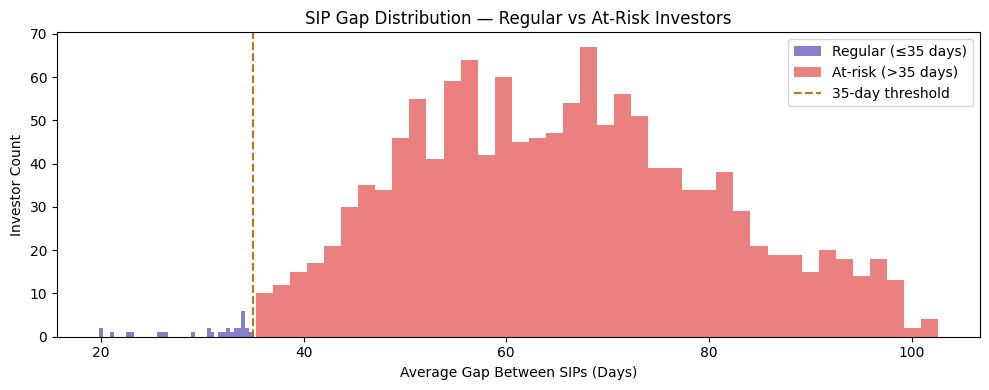

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# SIP Transactions Only
# --------------------------------------------------
sip_only = (
    txn[
        txn["transaction_type"]
        .astype(str)
        .str.upper()
        .eq("SIP")
    ]
    .sort_values(["investor_id", "transaction_date"])
    .copy()
)

# --------------------------------------------------
# Gap Between Consecutive SIPs
# --------------------------------------------------
sip_only["prev_date"] = (
    sip_only.groupby("investor_id")["transaction_date"]
            .shift(1)
)

sip_only["gap_days"] = (
    sip_only["transaction_date"] -
    sip_only["prev_date"]
).dt.days

# --------------------------------------------------
# Investors with >= 6 SIPs
# --------------------------------------------------
sip_counts = sip_only.groupby("investor_id").size()

qualified = sip_counts[
    sip_counts >= 6
].index

sip_qual = sip_only[
    sip_only["investor_id"].isin(qualified)
].copy()

# --------------------------------------------------
# Investor Continuity Metrics
# --------------------------------------------------
continuity = (
    sip_qual.groupby("investor_id")
            .agg(
                num_sips=("id", "count"),
                avg_gap_days=("gap_days", "mean"),
                max_gap_days=("gap_days", "max"),
                state=("state", "first"),
                age_group=("age_group", "first")
            )
            .reset_index()
)

continuity["avg_gap_days"] = (
    continuity["avg_gap_days"]
    .round(1)
)

continuity["max_gap_days"] = (
    continuity["max_gap_days"]
    .round(1)
)

# --------------------------------------------------
# At-Risk Flag
# --------------------------------------------------
continuity["at_risk"] = (
    continuity["avg_gap_days"] > 35
)

# --------------------------------------------------
# Summary Statistics
# --------------------------------------------------
total_q = len(continuity)

at_risk_n = int(
    continuity["at_risk"].sum()
)

safe_n = total_q - at_risk_n

print(f"Qualified investors (6+ SIPs): {total_q:,}")

print(
    f"At-risk (avg gap > 35 days): "
    f"{at_risk_n:,} "
    f"({at_risk_n/total_q*100:.1f}%)"
)

print(f"Safe investors: {safe_n:,}")

# --------------------------------------------------
# State-wise Risk Analysis
# --------------------------------------------------
state_risk = (
    continuity.groupby("state")["at_risk"]
              .agg(["sum", "count"])
)

state_risk["at_risk_pct"] = (
    state_risk["sum"] /
    state_risk["count"] * 100
).round(1)

state_risk = (
    state_risk.sort_values(
        "at_risk_pct",
        ascending=False
    )
)

print("\nTop states by at-risk SIP rate:\n")
print(state_risk.head(8).to_string())

# --------------------------------------------------
# Save Output
# --------------------------------------------------
continuity.to_csv(
    "../data/processed/sip_continuity.csv",
    index=False
)

print(
    "\nSaved: data/processed/sip_continuity.csv"
)

# --------------------------------------------------
# Visualization
# --------------------------------------------------
plt.figure(figsize=(10, 4))

plt.hist(
    continuity[
        ~continuity["at_risk"]
    ]["avg_gap_days"],
    bins=40,
    alpha=0.7,
    color="#534AB7",
    label="Regular (≤35 days)"
)

plt.hist(
    continuity[
        continuity["at_risk"]
    ]["avg_gap_days"],
    bins=40,
    alpha=0.7,
    color="#E24B4A",
    label="At-risk (>35 days)"
)

plt.axvline(
    35,
    color="#BA7517",
    linestyle="--",
    linewidth=1.5,
    label="35-day threshold"
)

plt.title(
    "SIP Gap Distribution — Regular vs At-Risk Investors"
)

plt.xlabel("Average Gap Between SIPs (Days)")
plt.ylabel("Investor Count")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../reports/charts/19_sip_continuity.png",
    dpi=150,
    bbox_inches="tight"
)

print(
    "Saved: reports/charts/19_sip_continuity.png"
)

plt.show()